# STEP 1 — Project Understanding

**Title:** Tesla Stock Price Prediction using SimpleRNN and LSTM (with NLP News Sentiment)

**Domain:** Financial Services

**Problem Statement:** Predict Tesla's closing stock price for 1-day, 5-day, and 10-day
horizons using SimpleRNN and LSTM deep learning models, compare their performance, and
additionally explore whether incorporating NLP-derived news sentiment as a feature
improves forecasting accuracy (baseline price-only models vs. NLP-enhanced models).

**Objectives:**
- Analyze and clean Tesla stock price data
- Analyze and clean Tesla-related text/news data (NLP)
- Perform EDA on price data and sentiment data
- Engineer features (moving averages, daily return, daily sentiment)
- Build SimpleRNN and LSTM models — baseline (price-only) and NLP-enhanced (price+sentiment)
- Predict 1-day, 5-day, and 10-day closing prices
- Tune hyperparameters with GridSearchCV
- Compare all models using MSE, RMSE, MAE


# STEP 2 — Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np
import pickle
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# NLP libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scikeras.wrappers import KerasRegressor

plt.style.use('seaborn-v0_8-darkgrid')
tf.random.set_seed(42)
np.random.seed(42)

print("All libraries imported successfully")


I0000 00:00:1786193610.967000     479 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786193626.959954     479 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786193637.414023     479 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


All libraries imported successfully


# STEP 3 — Load Dataset
Loading the Tesla stock price dataset (TSLA.csv) and an illustrative Tesla-related
text/social-media dataset for the NLP component (no historical news/social dataset was
supplied with this project, so a small illustrative set of real, dated Tesla news events
is used to demonstrate the full NLP pipeline end-to-end).


In [2]:
df = pd.read_csv("TSLA.csv")
print("Tesla stock data loaded:", df.shape)
df.head()


Tesla stock data loaded: (2416, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
raw_posts = pd.DataFrame([
    ("2013-05-09", "Tesla posts surprise first quarterly profit, shares soar"),
    ("2013-05-09", "Tesla posts surprise first quarterly profit, shares soar"),  # duplicate
    ("2013-08-05", "Tesla shares tumble after quarterly loss widens"),
    ("2014-02-20", "Tesla to build massive battery Gigafactory"),
    ("2014-02-20", "Analysts excited about Gigafactory scale and cost savings"),
    ("2014-10-01", "Tesla unveils Autopilot hardware for Model S"),
    ("2016-05-04", "Tesla posts wider-than-expected quarterly loss"),
    ("2016-08-01", "Tesla to acquire SolarCity in controversial deal"),
    ("2017-04-03", "Tesla passes Ford in market value amid delivery growth"),
    ("2018-04-05", "Tesla recalls thousands of Model X SUVs over steering flaw"),
    ("2018-08-07", "Musk says considering taking Tesla private, stock jumps"),
    ("2018-08-07", "Investors uneasy about going-private funding claims"),
    ("2018-10-24", "Tesla posts record profit, shares surge on strong deliveries"),
    ("2019-01-30", "Tesla misses delivery targets, shares fall sharply"),
    ("2019-04-24", "Tesla reports steep quarterly loss, cash concerns weigh on stock"),
    ("2019-10-23", "Tesla surprises with profit, shares rally on strong China demand"),
    ("2020-01-29", "Tesla posts fifth straight profitable quarter, stock rallies"),
    ("2020-02-03", "Tesla shares surge to record high amid short squeeze"),
    ("2020-02-03", ""),          # blank text row (demonstrates empty-text removal)
    ("2015-06-15", None),        # missing text row (demonstrates missing-text handling)
], columns=["Date", "Text"])
print("Raw Tesla text/social-media dataset loaded:", raw_posts.shape)
raw_posts


Raw Tesla text/social-media dataset loaded: (20, 2)


,Date,Text
0,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
1,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
2,2013-08-05,Tesla shares tumble after quarterly loss widens
3,2014-02-20,Tesla to build massive battery Gigafactory
4,2014-02-20,Analysts excited about Gigafactory scale and c...
5,2014-10-01,Tesla unveils Autopilot hardware for Model S
6,2016-05-04,Tesla posts wider-than-expected quarterly loss
7,2016-08-01,Tesla to acquire SolarCity in controversial deal
8,2017-04-03,Tesla passes Ford in market value amid deliver...
9,2018-04-05,Tesla recalls thousands of Model X SUVs over s...


# STEP 4 — Data Understanding

In [4]:
print("STOCK DATA")
print(df.head())
print(df.tail())
print("Shape:", df.shape)
df.info()


STOCK DATA
         Date       Open   High        Low      Close  Adj Close    Volume
0  2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900
            Date        Open        High         Low       Close   Adj Close  \
2411  2020-01-28  568.489990  576.809998  558.080017  566.900024  566.900024   
2412  2020-01-29  575.690002  589.799988  567.429993  580.989990  580.989990   
2413  2020-01-30  632.419983  650.880005  618.000000  640.809998  640.809998   
2414  2020-01-31  640.000000  653.000000  632.520020  650.570007  650.570007   
2415  2020-02-03  673.690002  786.140015  673.520020  780.000000  780.000000   

        Volume  
2411  11788500  
2412  17801500  
2413  2

In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [6]:
print("Columns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)


Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Dtypes:
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [7]:
print("NLP TEXT DATA")
print(raw_posts.head())
print("Shape:", raw_posts.shape)
raw_posts.info()


NLP TEXT DATA
         Date                                               Text
0  2013-05-09  Tesla posts surprise first quarterly profit, s...
1  2013-05-09  Tesla posts surprise first quarterly profit, s...
2  2013-08-05    Tesla shares tumble after quarterly loss widens
3  2014-02-20         Tesla to build massive battery Gigafactory
4  2014-02-20  Analysts excited about Gigafactory scale and c...
Shape: (20, 2)
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    20 non-null     str  
 1   Text    19 non-null     str  
dtypes: str(2)
memory usage: 452.0 bytes


# STEP 5 — Data Cleaning

**Stock data:** missing values, duplicates, date conversion, date sorting, consistency check.

**NLP data:** missing text, duplicate text, date conversion, empty-text removal.


In [8]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.set_index("Date", inplace=True)
print("\nDate converted & sorted. Monotonic index:", df.index.is_monotonic_increasing)
assert df.isnull().sum().sum() == 0
df.head()


Missing values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate rows: 0

Date converted & sorted. Monotonic index: True


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [9]:
posts = raw_posts.copy()
print("Missing text rows:", posts["Text"].isnull().sum())
posts = posts.dropna(subset=["Text"])                                # remove missing text

print("Duplicate text rows:", posts.duplicated(subset=["Date","Text"]).sum())
posts = posts.drop_duplicates(subset=["Date","Text"])                # remove duplicate text

posts["Date"] = pd.to_datetime(posts["Date"])                        # date conversion
posts["Text"] = posts["Text"].astype(str).str.strip()
posts = posts[posts["Text"].str.len() > 0].reset_index(drop=True)    # remove empty text

print("Cleaned NLP dataset shape:", posts.shape)
posts


Missing text rows: 1
Duplicate text rows: 1
Cleaned NLP dataset shape: (17, 2)


,Date,Text
0,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
1,2013-08-05,Tesla shares tumble after quarterly loss widens
2,2014-02-20,Tesla to build massive battery Gigafactory
3,2014-02-20,Analysts excited about Gigafactory scale and c...
4,2014-10-01,Tesla unveils Autopilot hardware for Model S
5,2016-05-04,Tesla posts wider-than-expected quarterly loss
6,2016-08-01,Tesla to acquire SolarCity in controversial deal
7,2017-04-03,Tesla passes Ford in market value amid deliver...
8,2018-04-05,Tesla recalls thousands of Model X SUVs over s...
9,2018-08-07,"Musk says considering taking Tesla private, st..."


# STEP 6 — EDA (Stock Data)

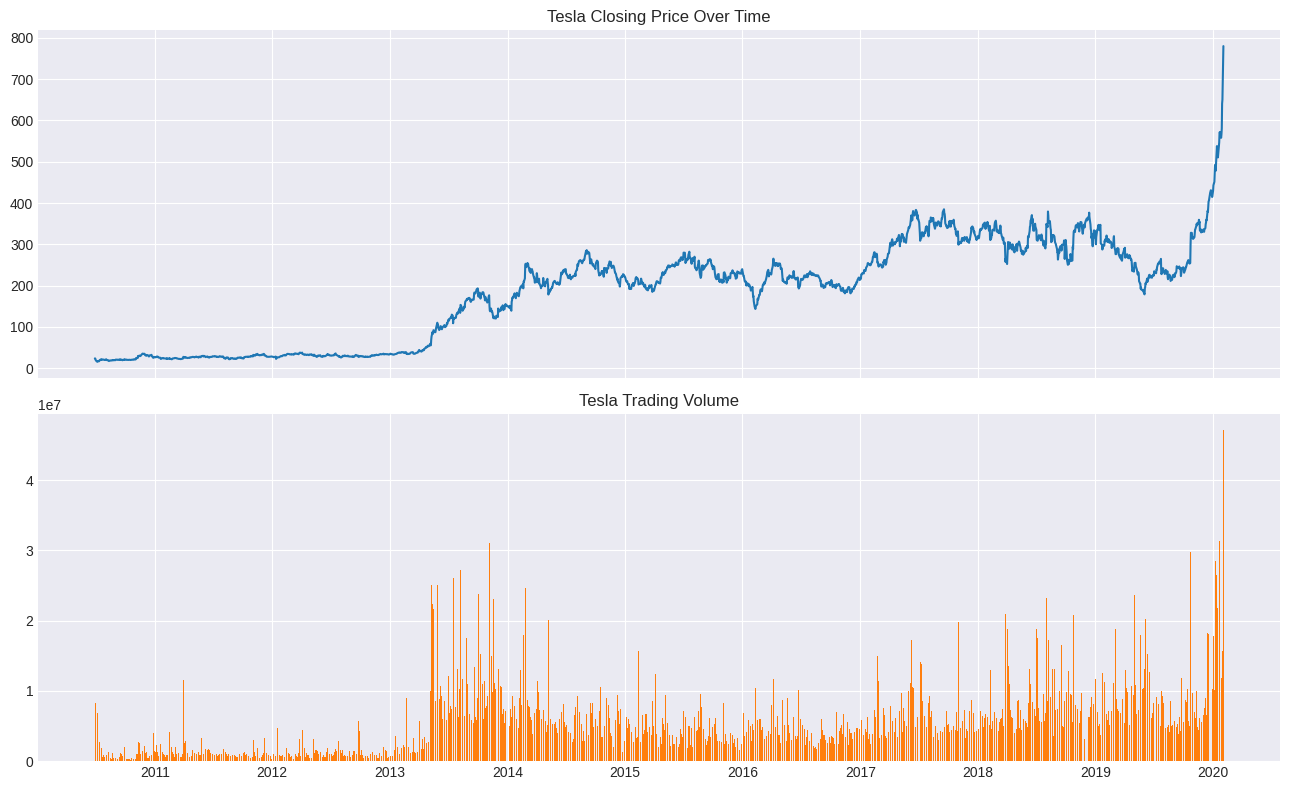

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(df.index, df["Close"], color="#1f77b4")
axes[0].set_title("Tesla Closing Price Over Time")
axes[1].bar(df.index, df["Volume"], color="#ff7f0e", width=1.0)
axes[1].set_title("Tesla Trading Volume")
plt.tight_layout(); plt.show()


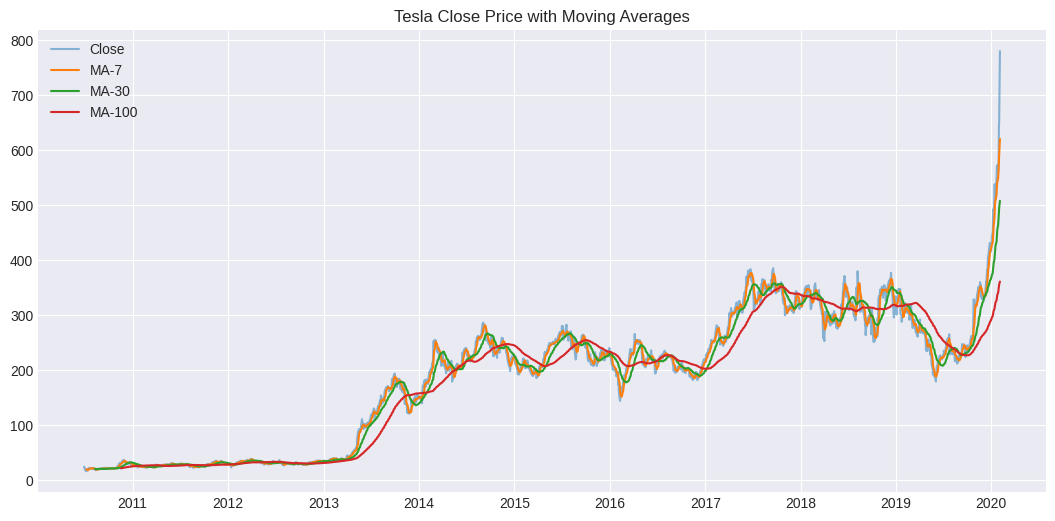

In [11]:
df["MA7"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["MA100"] = df["Close"].rolling(100).mean()
plt.figure(figsize=(13,6))
plt.plot(df["Close"], label="Close", alpha=0.5)
plt.plot(df["MA7"], label="MA-7"); plt.plot(df["MA30"], label="MA-30"); plt.plot(df["MA100"], label="MA-100")
plt.title("Tesla Close Price with Moving Averages"); plt.legend(); plt.show()


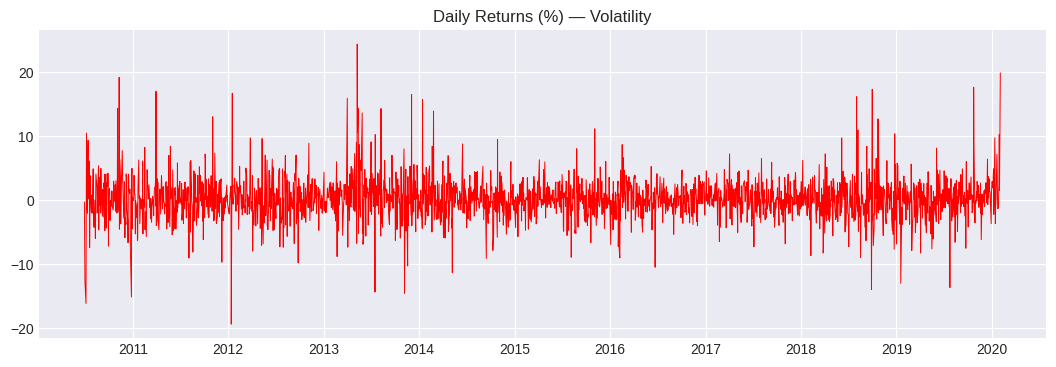

In [12]:
df["Daily_Return"] = df["Close"].pct_change() * 100
plt.figure(figsize=(13,4))
plt.plot(df["Daily_Return"], color="red", linewidth=0.7)
plt.title("Daily Returns (%) — Volatility"); plt.show()


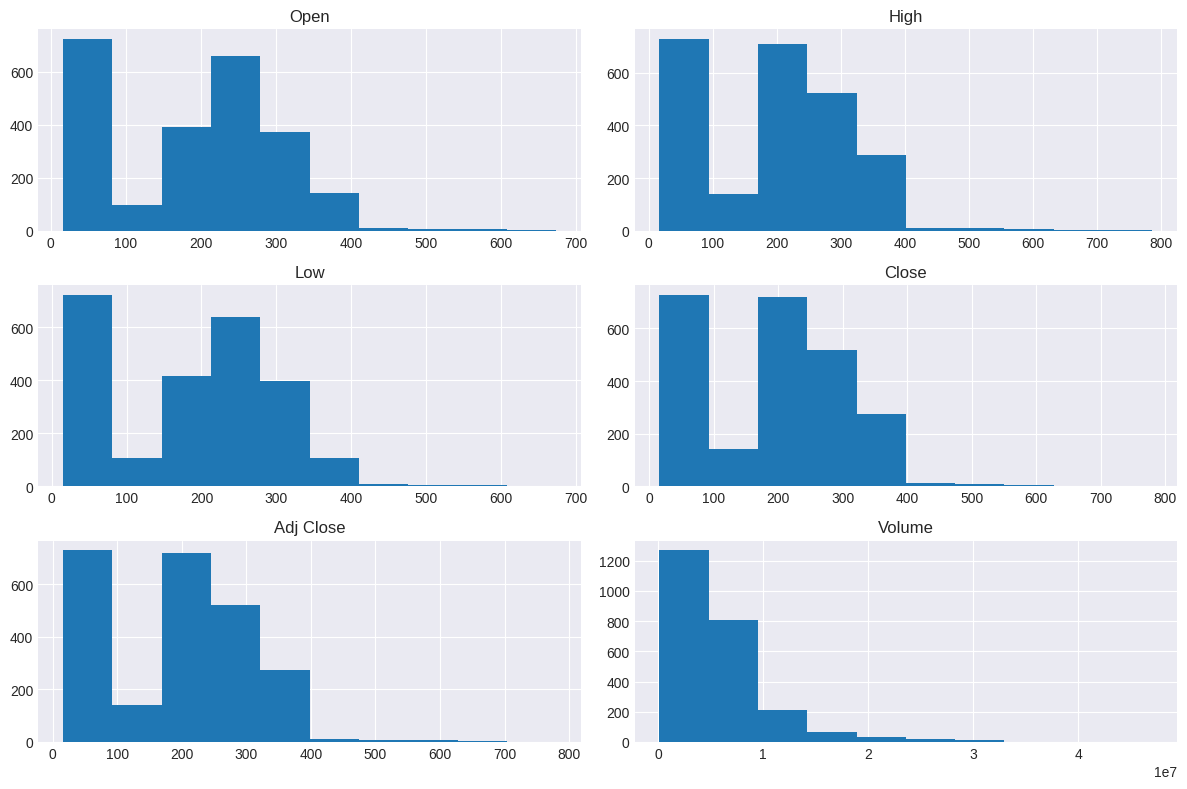

In [13]:
df[["Open","High","Low","Close","Adj Close","Volume"]].hist(figsize=(12,8))
plt.tight_layout(); plt.show()


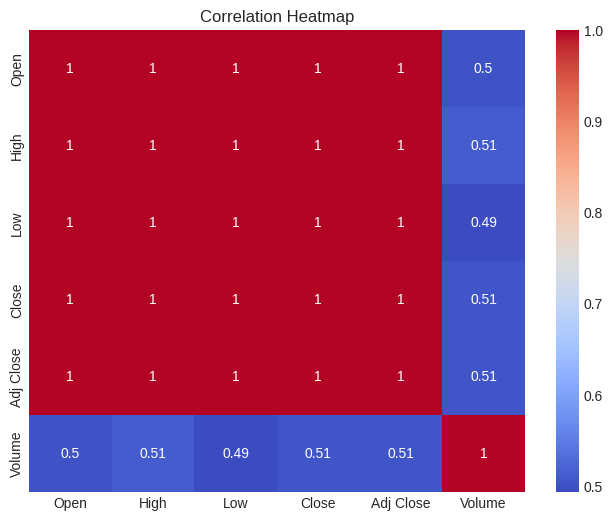

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open","High","Low","Close","Adj Close","Volume"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap"); plt.show()


# STEP 7 — NLP Text Preprocessing
- Convert text to lowercase
- Remove unnecessary characters
- Remove unwanted spaces


In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

posts["Clean_Text"] = posts["Text"].apply(clean_text)
posts[["Text", "Clean_Text"]]


,Text,Clean_Text
0,"Tesla posts surprise first quarterly profit, s...",tesla posts surprise first quarterly profit sh...
1,Tesla shares tumble after quarterly loss widens,tesla shares tumble after quarterly loss widens
2,Tesla to build massive battery Gigafactory,tesla to build massive battery gigafactory
3,Analysts excited about Gigafactory scale and c...,analysts excited about gigafactory scale and c...
4,Tesla unveils Autopilot hardware for Model S,tesla unveils autopilot hardware for model s
5,Tesla posts wider-than-expected quarterly loss,tesla posts widerthanexpected quarterly loss
6,Tesla to acquire SolarCity in controversial deal,tesla to acquire solarcity in controversial deal
7,Tesla passes Ford in market value amid deliver...,tesla passes ford in market value amid deliver...
8,Tesla recalls thousands of Model X SUVs over s...,tesla recalls thousands of model x suvs over s...
9,"Musk says considering taking Tesla private, st...",musk says considering taking tesla private sto...


# STEP 8 — NLP Sentiment Analysis
Generate a sentiment score for each headline using VADER, classify it as
Positive / Neutral / Negative, and create a numerical sentiment feature.


In [16]:
analyzer = SentimentIntensityAnalyzer()

def score_sentiment(text):
    s = analyzer.polarity_scores(text)["compound"]
    if s >= 0.05:
        label = "Positive"
    elif s <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return pd.Series([s, label])

posts[["Sentiment_Score", "Sentiment_Label"]] = posts["Clean_Text"].apply(score_sentiment)
posts[["Date", "Text", "Sentiment_Score", "Sentiment_Label"]]


,Date,Text,Sentiment_Score,Sentiment_Label
0,2013-05-09,"Tesla posts surprise first quarterly profit, s...",0.7351,Positive
1,2013-08-05,Tesla shares tumble after quarterly loss widens,-0.0258,Neutral
2,2014-02-20,Tesla to build massive battery Gigafactory,0.0000,Neutral
3,2014-02-20,Analysts excited about Gigafactory scale and c...,0.3400,Positive
4,2014-10-01,Tesla unveils Autopilot hardware for Model S,0.0000,Neutral
5,2016-05-04,Tesla posts wider-than-expected quarterly loss,-0.3182,Negative
6,2016-08-01,Tesla to acquire SolarCity in controversial deal,-0.2023,Negative
7,2017-04-03,Tesla passes Ford in market value amid deliver...,0.6124,Positive
8,2018-04-05,Tesla recalls thousands of Model X SUVs over s...,0.0000,Neutral
9,2018-08-07,"Musk says considering taking Tesla private, st...",0.0000,Neutral


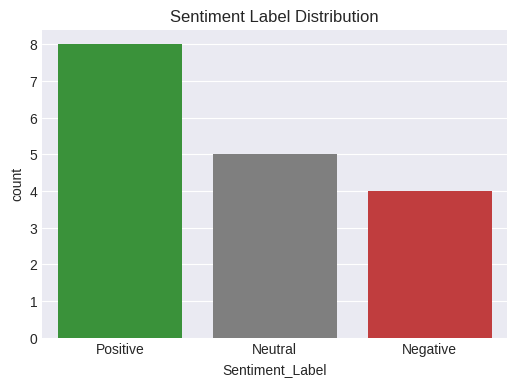

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=posts, x="Sentiment_Label", order=["Positive","Neutral","Negative"],
              palette={"Positive":"#2ca02c","Neutral":"#7f7f7f","Negative":"#d62728"})
plt.title("Sentiment Label Distribution"); plt.show()


# STEP 9 — Date-wise NLP Aggregation
When several texts belong to the same date, aggregate their sentiment scores into a
single daily average sentiment value.


In [18]:
daily_sentiment = posts.groupby("Date")["Sentiment_Score"].mean().reset_index()
daily_sentiment.columns = ["Date", "Daily_Sentiment"]
daily_sentiment


,Date,Daily_Sentiment
0,2013-05-09,0.7351
1,2013-08-05,-0.0258
2,2014-02-20,0.1700
3,2014-10-01,0.0000
4,2016-05-04,-0.3182
5,2016-08-01,-0.2023
6,2017-04-03,0.6124
7,2018-04-05,0.0000
8,2018-08-07,-0.1909
9,2018-10-24,0.8126


# STEP 10 — Merge Stock + NLP Data
Merge the daily aggregated sentiment onto the full trading calendar. Trading days without
a matched headline get no direct sentiment reading — we forward-fill the most recent known
sentiment for up to 5 trading days (a headline's influence reasonably persists briefly),
and treat any day beyond that reach as neutral (0). This is a defensible, documented
choice given the sparse illustrative headline set used here.


In [19]:
stock_reset = df.reset_index()[["Date", "Adj Close"]]
combined = pd.merge(stock_reset, daily_sentiment, on="Date", how="left")

combined["Daily_Sentiment"] = combined["Daily_Sentiment"].ffill(limit=5)
combined["Daily_Sentiment"] = combined["Daily_Sentiment"].fillna(0.0)

print("Combined shape:", combined.shape)
print("Non-neutral sentiment days:", (combined["Daily_Sentiment"] != 0).sum(), "/", len(combined))
combined.set_index("Date", inplace=True)
combined.head(10)


Combined shape: (2416, 3)
Non-neutral sentiment days: 70 / 2416


,Adj Close,Daily_Sentiment
Date,,
2010-06-29,23.889999,0.0
2010-06-30,23.830000,0.0
2010-07-01,21.959999,0.0
2010-07-02,19.200001,0.0
2010-07-06,16.110001,0.0
2010-07-07,15.800000,0.0
2010-07-08,17.459999,0.0
2010-07-09,17.400000,0.0
2010-07-12,17.049999,0.0


# STEP 11 — Feature Engineering
- Adj Close -> target variable
- MA7, MA30, MA100 -> trend context
- Daily_Return -> volatility context
- NLP Sentiment Score -> additional model input (NLP-enhanced variant)


In [20]:
combined["MA7"] = combined["Adj Close"].rolling(7).mean()
combined["MA30"] = combined["Adj Close"].rolling(30).mean()
combined["MA100"] = combined["Adj Close"].rolling(100).mean()
combined["Daily_Return"] = combined["Adj Close"].pct_change() * 100
combined.to_csv("combined_features.csv")
combined.tail()


,Adj Close,Daily_Sentiment,MA7,MA30,MA100,Daily_Return
Date,,,,,,
2020-01-28,566.900024,0.0000,555.600010,469.665002,343.527601,1.591341
2020-01-29,580.989990,0.5859,565.670009,477.085002,347.041701,2.485441
2020-01-30,640.809998,0.5859,579.042864,485.728668,351.175301,10.296220
2020-01-31,650.570007,0.5859,590.615723,494.781335,355.363101,1.523074
2020-02-03,780.000000,0.2960,620.301435,507.676336,360.807701,19.894860


# STEP 12 — Train-Test Split
Chronological split — 80% train, 20% test — no shuffling, to preserve time-series order.


In [21]:
SPLIT_RATIO = 0.8
split_point = int(len(combined) * SPLIT_RATIO)
print(f"Split date: {combined.index[split_point].date()}  (Train={split_point}, Test={len(combined)-split_point})")

price_all = combined[["Adj Close"]].values
sentiment_all = combined[["Daily_Sentiment"]].values

price_train_raw, price_test_raw = price_all[:split_point], price_all[split_point:]
sent_train_raw, sent_test_raw = sentiment_all[:split_point], sentiment_all[split_point:]


Split date: 2018-03-02  (Train=1932, Test=484)


# STEP 13 — Data Scaling
MinMaxScaler, fit ONLY on training data, then applied to test data — avoiding data leakage.
Separate scalers are used for price and sentiment since they have different distributions.


In [22]:
price_scaler = MinMaxScaler(feature_range=(0,1))
price_scaler.fit(price_train_raw)
price_train_scaled = price_scaler.transform(price_train_raw)
price_test_scaled = price_scaler.transform(price_test_raw)

sent_scaler = MinMaxScaler(feature_range=(0,1))
sent_scaler.fit(sent_train_raw)
sent_train_scaled = sent_scaler.transform(sent_train_raw)
sent_test_scaled = sent_scaler.transform(sent_test_raw)

price_full_scaled = np.concatenate([price_train_scaled, price_test_scaled], axis=0)
sent_full_scaled = np.concatenate([sent_train_scaled, sent_test_scaled], axis=0)

with open("price_scaler.pkl","wb") as f: pickle.dump(price_scaler, f)
with open("sent_scaler.pkl","wb") as f: pickle.dump(sent_scaler, f)
print("Scaling complete — both scalers fit on TRAIN data only.")


Scaling complete — both scalers fit on TRAIN data only.


# STEP 14 — Time-Series Sequence Creation
60-day lookback window. Two sets of sequences are built per horizon (1-day, 5-day, 10-day):
- **Baseline**: 1 feature per timestep -> [price]
- **NLP-Enhanced**: 2 features per timestep -> [price, sentiment]


In [23]:
WINDOW = 60
HORIZONS = [1, 5, 10]

def create_sequences_multi(price_series, extra_series, window, horizon, use_extra=False):
    X, y = [], []
    for i in range(len(price_series) - window - horizon + 1):
        if use_extra:
            seq = np.concatenate([price_series[i:i+window], extra_series[i:i+window]], axis=1)
        else:
            seq = price_series[i:i+window]
        X.append(seq)
        y.append(price_series[i+window+horizon-1, 0])
    return np.array(X), np.array(y)

datasets_baseline = {}
datasets_enhanced = {}

for h in HORIZONS:
    Xb, yb = create_sequences_multi(price_full_scaled, sent_full_scaled, WINDOW, h, use_extra=False)
    Xe, ye = create_sequences_multi(price_full_scaled, sent_full_scaled, WINDOW, h, use_extra=True)
    n_test = max(len(price_test_scaled) - h + 1, 1)
    datasets_baseline[h] = dict(X_train=Xb[:-n_test], y_train=yb[:-n_test], X_test=Xb[-n_test:], y_test=yb[-n_test:])
    datasets_enhanced[h] = dict(X_train=Xe[:-n_test], y_train=ye[:-n_test], X_test=Xe[-n_test:], y_test=ye[-n_test:])
    print(f"Horizon {h}d -> baseline X_train {datasets_baseline[h]['X_train'].shape}, "
          f"enhanced X_train {datasets_enhanced[h]['X_train'].shape}")

with open("datasets_baseline.pkl","wb") as f: pickle.dump(datasets_baseline, f)
with open("datasets_enhanced.pkl","wb") as f: pickle.dump(datasets_enhanced, f)


Horizon 1d -> baseline X_train (1872, 60, 1), enhanced X_train (1872, 60, 2)
Horizon 5d -> baseline X_train (1872, 60, 1), enhanced X_train (1872, 60, 2)
Horizon 10d -> baseline X_train (1872, 60, 1), enhanced X_train (1872, 60, 2)


# STEP 15 — SimpleRNN Architecture

In [24]:
def build_simplernn(window, n_features, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(window, n_features)),
        Dropout(dropout),
        SimpleRNN(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

build_simplernn(WINDOW, 1).summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

# STEP 16 — LSTM Architecture

In [25]:
def build_lstm(window, n_features, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(window, n_features)),
        Dropout(dropout),
        LSTM(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

build_lstm(WINDOW, 2).summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,601 (115.63 KB)

 Trainable params: 29,601 (115.63 KB)

 Non-trainable params: 0 (0.00 B)

# STEP 17 — Model Compilation
Both architectures are compiled with Mean Squared Error loss and the Adam optimizer (done inside the builder functions above).

# STEP 18 — Model Training Configuration
- Epochs: up to 50
- Batch size: 32
- Validation: validation_split=0.1 (from TRAINING data only — never the test set)
- EarlyStopping: patience=8, restore_best_weights=True
- ModelCheckpoint: saves the best model per (variant, architecture, horizon)


# STEP 19 — Train Models
Two variants, trained across both architectures and all three horizons (12 models total):
- **Without NLP = Baseline** (price-only)
- **With NLP = Enhanced** (price + sentiment)

SimpleRNN -> 1/5/10-day, LSTM -> 1/5/10-day, for each variant.


In [26]:
results = {}
histories = {}
variants = [("Baseline", datasets_baseline, 1), ("NLP_Enhanced", datasets_enhanced, 2)]

for variant_name, datasets, n_features in variants:
    for h in HORIZONS:
        Xtr, ytr = datasets[h]['X_train'], datasets[h]['y_train']
        Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']
        for arch, builder in [("SimpleRNN", build_simplernn), ("LSTM", build_lstm)]:
            print(f"Training {variant_name} | {arch} | horizon={h}d | features={n_features}")
            model = builder(WINDOW, n_features)
            ckpt = f"best_{variant_name}_{arch}_h{h}.keras"
            cbs = [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
                   ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True)]
            hist = model.fit(Xtr, ytr, validation_split=0.1, epochs=50, batch_size=32, callbacks=cbs, verbose=0)
            test_loss = model.evaluate(Xte, yte, verbose=0)
            print(f"  -> epochs: {len(hist.history['loss'])}, val_loss: {hist.history['val_loss'][-1]:.6f}, "
                  f"test loss(scaled): {test_loss:.6f}")
            key = f"{variant_name}_{arch}_h{h}"
            results[key] = dict(model_path=ckpt, variant=variant_name, arch=arch, horizon=h)
            histories[key] = hist.history

print(f"\nAll {len(results)} models trained (2 variants x 2 architectures x 3 horizons).")


Training Baseline | SimpleRNN | horizon=1d | features=1


  -> epochs: 9, val_loss: 0.007977, test loss(scaled): 0.012438
Training Baseline | LSTM | horizon=1d | features=1


  -> epochs: 18, val_loss: 0.002716, test loss(scaled): 0.005480
Training Baseline | SimpleRNN | horizon=5d | features=1


  -> epochs: 25, val_loss: 0.004470, test loss(scaled): 0.009714
Training Baseline | LSTM | horizon=5d | features=1


  -> epochs: 10, val_loss: 0.003593, test loss(scaled): 0.011569
Training Baseline | SimpleRNN | horizon=10d | features=1


...

  -> epochs: 25, val_loss: 0.002533, test loss(scaled): 0.004738
Training NLP_Enhanced | SimpleRNN | horizon=5d | features=2


  -> epochs: 15, val_loss: 0.002823, test loss(scaled): 0.008607
Training NLP_Enhanced | LSTM | horizon=5d | features=2


  -> epochs: 10, val_loss: 0.004672, test loss(scaled): 0.012204
Training NLP_Enhanced | SimpleRNN | horizon=10d | features=2


  -> epochs: 12, val_loss: 0.003807, test loss(scaled): 0.018391
Training NLP_Enhanced | LSTM | horizon=10d | features=2


  -> epochs: 15, val_loss: 0.005469, test loss(scaled): 0.015212

All 12 models trained (2 variants x 2 architectures x 3 horizons).


# STEP 20 — Model Evaluation (MSE, RMSE, MAE)

In [27]:
eval_rows = []
predictions_store = {}

for variant_name, datasets, n_features in variants:
    for h in HORIZONS:
        Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']
        y_actual = price_scaler.inverse_transform(yte.reshape(-1,1))
        for arch in ["SimpleRNN", "LSTM"]:
            key = f"{variant_name}_{arch}_h{h}"
            model = load_model(results[key]['model_path'])
            pred_scaled = model.predict(Xte, verbose=0)
            pred = price_scaler.inverse_transform(pred_scaled)
            mse = mean_squared_error(y_actual, pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_actual, pred)
            eval_rows.append({"Variant": variant_name, "Model": arch, "Horizon": h, "MSE": mse, "RMSE": rmse, "MAE": mae})
            predictions_store[key] = dict(actual=y_actual, pred=pred)

comparison = pd.DataFrame(eval_rows).sort_values(["Horizon","Variant","Model"]).reset_index(drop=True)
comparison


,Variant,Model,Horizon,MSE,RMSE,MAE
0,Baseline,LSTM,1,746.924148,27.329913,18.142728
1,Baseline,SimpleRNN,1,1695.396978,41.175199,26.913949
2,NLP_Enhanced,LSTM,1,645.876987,25.414110,17.476988
3,NLP_Enhanced,SimpleRNN,1,447.995421,21.165902,13.475908
4,Baseline,LSTM,5,1576.993335,39.711375,27.572465
5,Baseline,SimpleRNN,5,1324.129608,36.388592,22.793771
6,NLP_Enhanced,LSTM,5,1663.522419,40.786302,27.435913
7,NLP_Enhanced,SimpleRNN,5,1173.181351,34.251735,22.660899
8,Baseline,LSTM,10,2184.273032,46.736207,32.420767
9,Baseline,SimpleRNN,10,1821.926943,42.684036,29.520830


# STEP 21 — Actual vs Predicted

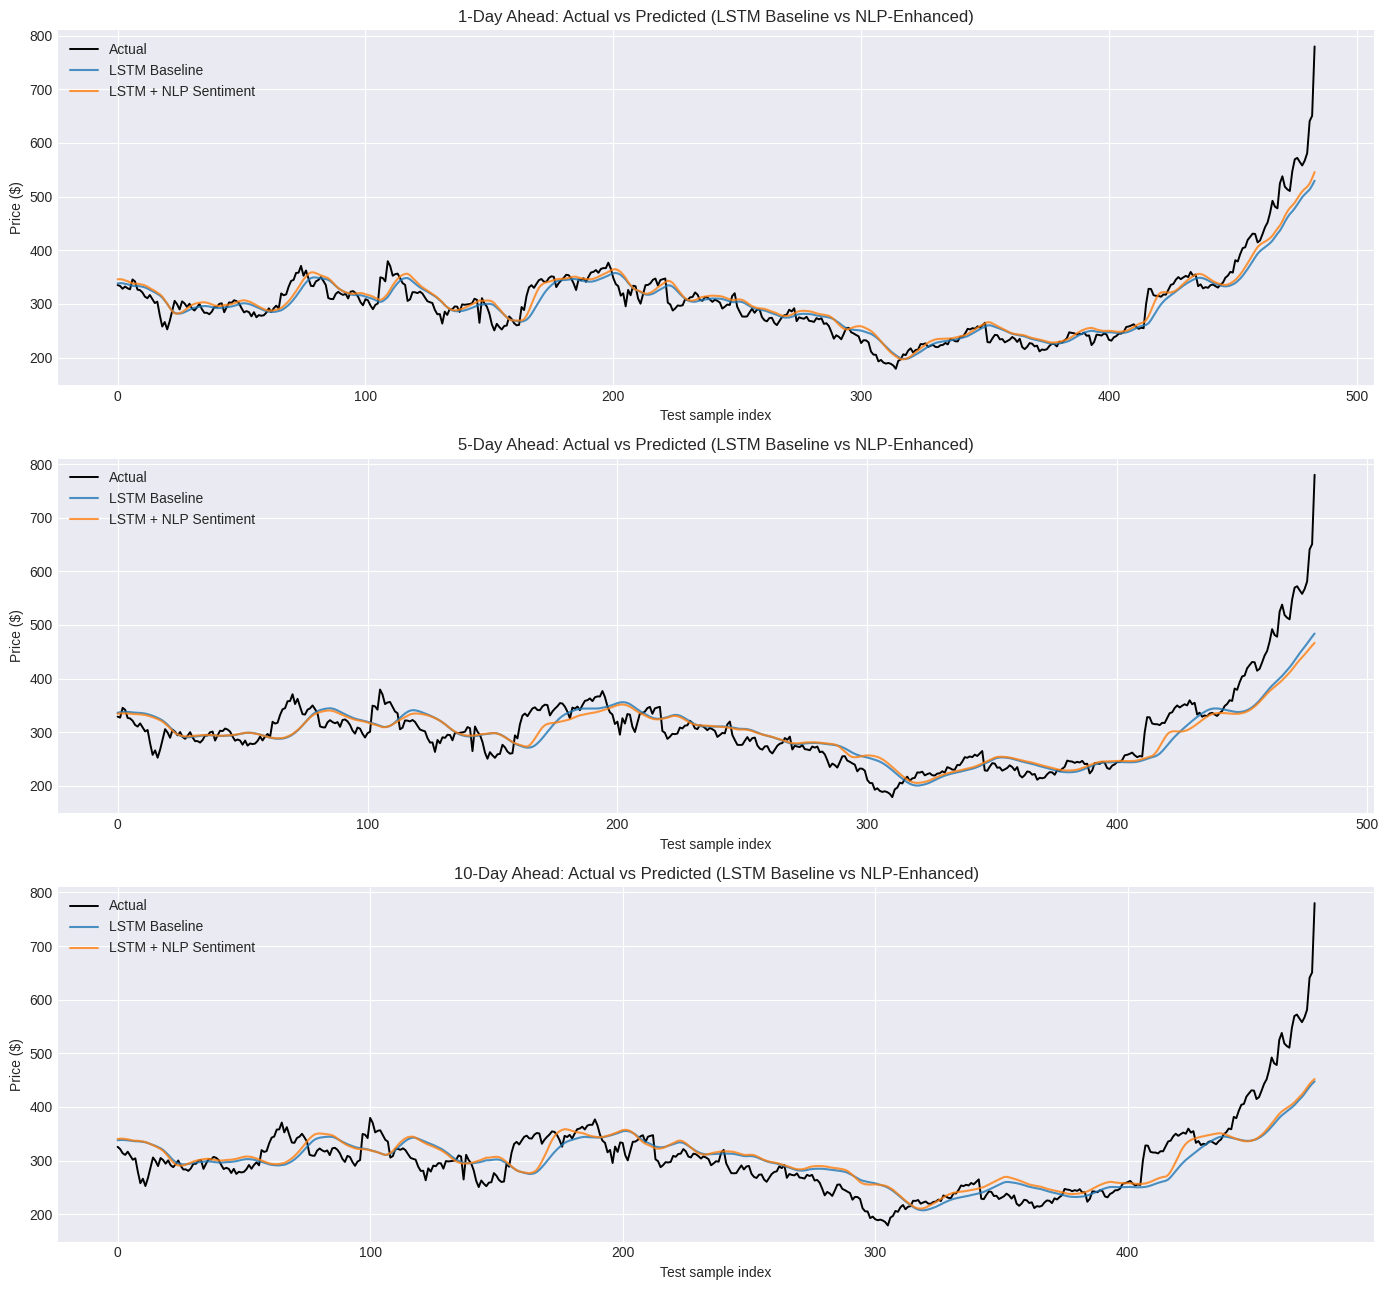

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
for ax, h in zip(axes, HORIZONS):
    ax.plot(predictions_store[f"Baseline_LSTM_h{h}"]["actual"], label="Actual", color="black", linewidth=1.4)
    ax.plot(predictions_store[f"Baseline_LSTM_h{h}"]["pred"], label="LSTM Baseline", alpha=0.8)
    ax.plot(predictions_store[f"NLP_Enhanced_LSTM_h{h}"]["pred"], label="LSTM + NLP Sentiment", alpha=0.8)
    ax.set_title(f"{h}-Day Ahead: Actual vs Predicted (LSTM Baseline vs NLP-Enhanced)")
    ax.set_xlabel("Test sample index"); ax.set_ylabel("Price ($)"); ax.legend()
plt.tight_layout(); plt.show()


# STEP 22 — Training vs Validation Loss
Checking learning behaviour and overfitting across all 12 models.

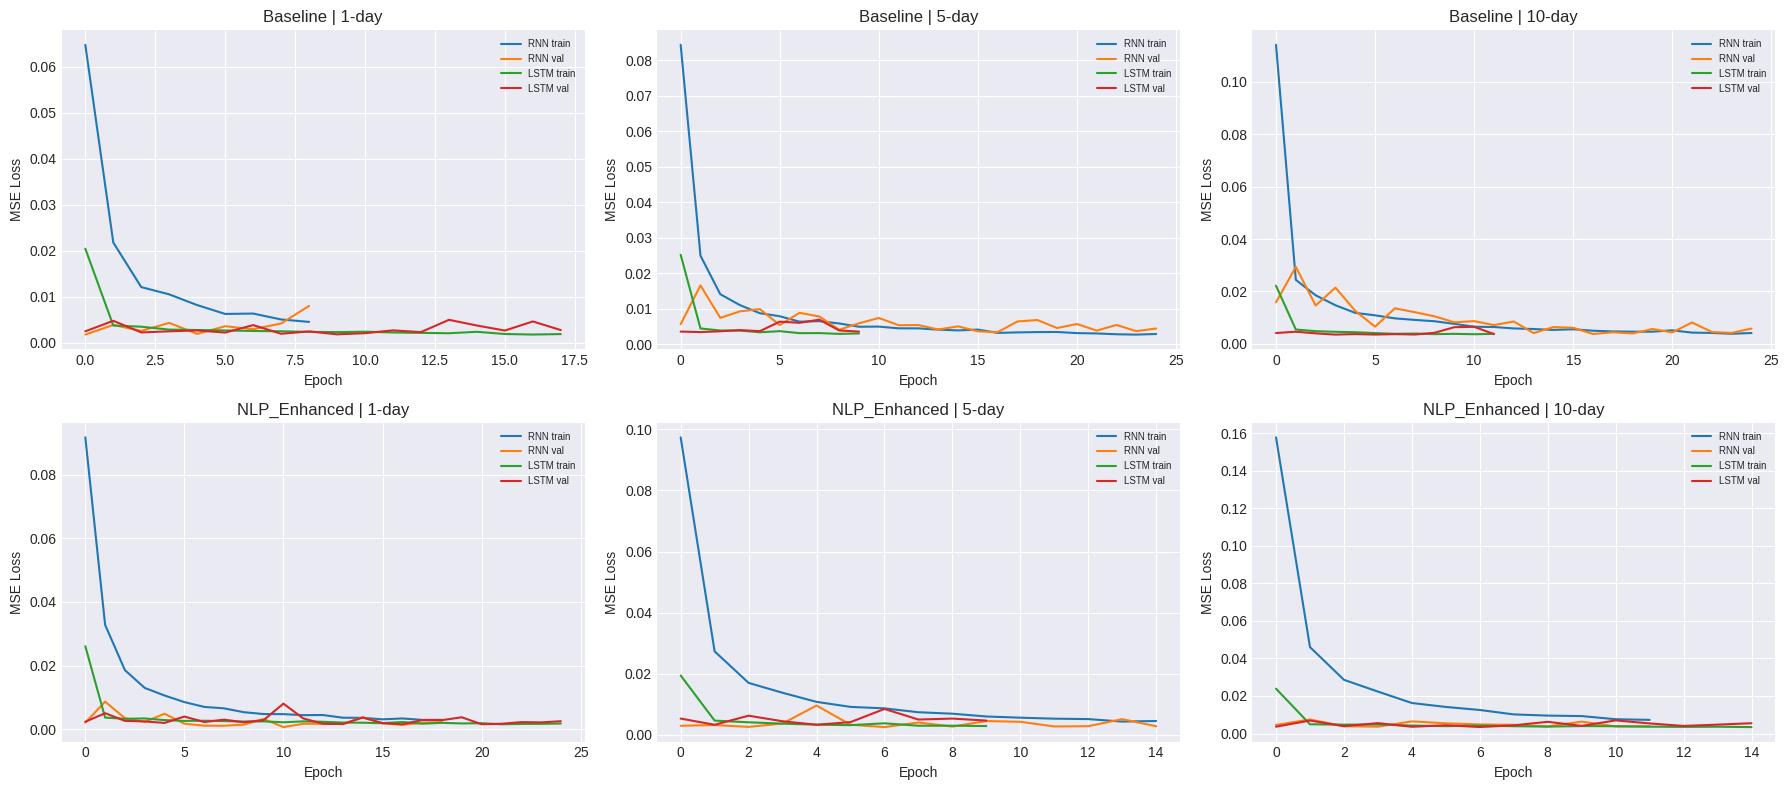

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for col, h in enumerate(HORIZONS):
    for row, variant_name in enumerate(["Baseline", "NLP_Enhanced"]):
        ax = axes[row, col]
        ax.plot(histories[f"{variant_name}_SimpleRNN_h{h}"]["loss"], label="RNN train")
        ax.plot(histories[f"{variant_name}_SimpleRNN_h{h}"]["val_loss"], label="RNN val")
        ax.plot(histories[f"{variant_name}_LSTM_h{h}"]["loss"], label="LSTM train")
        ax.plot(histories[f"{variant_name}_LSTM_h{h}"]["val_loss"], label="LSTM val")
        ax.set_title(f"{variant_name} | {h}-day")
        ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


# STEP 23 — GridSearchCV ⭐ (Mandatory Requirement)
Tuning LSTM units, dropout rate, and learning rate using GridSearchCV
(via a scikeras KerasRegressor wrapper), on the baseline 1-day dataset.


In [30]:
def build_lstm_for_grid(units=64, dropout=0.2, learning_rate=0.001):
    return build_lstm(WINDOW, 1, units=units, dropout=dropout, learning_rate=learning_rate)

Xtr1, ytr1 = datasets_baseline[1]['X_train'], datasets_baseline[1]['y_train']
reg = KerasRegressor(model=build_lstm_for_grid, verbose=0, epochs=8, batch_size=32)
param_grid = {
    "model__units": [32, 64],
    "model__dropout": [0.2, 0.3],
    "model__learning_rate": [0.001, 0.005],
}
grid = GridSearchCV(estimator=reg, param_grid=param_grid, scoring="neg_mean_squared_error", cv=2, n_jobs=1)
grid_result = grid.fit(Xtr1, ytr1)

print("Best params:", grid_result.best_params_)
print("Best CV score (neg MSE):", grid_result.best_score_)


Best params: {'model__dropout': 0.3, 'model__learning_rate': 0.001, 'model__units': 64}
Best CV score (neg MSE): -0.0014566773811868308


In [31]:
grid_df = pd.DataFrame(grid_result.cv_results_)[
    ["param_model__units","param_model__dropout","param_model__learning_rate","mean_test_score","rank_test_score"]
].sort_values("rank_test_score")
grid_df.columns = ["Units","Dropout","Learning Rate","Mean CV Score","Rank"]
grid_df


,Units,Dropout,Learning Rate,Mean CV Score,Rank
5,64,0.3,0.001,-0.001457,1
6,32,0.3,0.005,-0.002504,2
2,32,0.2,0.005,-0.002624,3
3,64,0.2,0.005,-0.003077,4
1,64,0.2,0.001,-0.003692,5
7,64,0.3,0.005,-0.003947,6
0,32,0.2,0.001,-0.004785,7
4,32,0.3,0.001,-0.005535,8


# STEP 24 — Best Hyperparameters

In [32]:
best_params = {k.replace("model__",""): v for k,v in grid_result.best_params_.items()}
print("Best hyperparameter combination found by GridSearchCV:", best_params)


Best hyperparameter combination found by GridSearchCV: {'dropout': 0.3, 'learning_rate': 0.001, 'units': 64}


# STEP 25 — Tuned LSTM
Training and evaluating the LSTM (1-day, baseline) using the selected best hyperparameters.

In [33]:
tuned_model = build_lstm(WINDOW, 1, **best_params)
cbs = [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
       ModelCheckpoint("best_tuned_LSTM_h1.keras", monitor="val_loss", save_best_only=True)]
tuned_hist = tuned_model.fit(Xtr1, ytr1, validation_split=0.1, epochs=50, batch_size=32, callbacks=cbs, verbose=0)

Xte1, yte1 = datasets_baseline[1]['X_test'], datasets_baseline[1]['y_test']
y_actual1 = price_scaler.inverse_transform(yte1.reshape(-1,1))
pred_tuned = price_scaler.inverse_transform(tuned_model.predict(Xte1, verbose=0))
tuned_mse = mean_squared_error(y_actual1, pred_tuned)
tuned_rmse = np.sqrt(tuned_mse)

baseline_lstm_1d_rmse = comparison[(comparison.Variant=="Baseline") & (comparison.Model=="LSTM") & (comparison.Horizon==1)]["RMSE"].values[0]
print(f"Tuned LSTM (1-day) RMSE: {tuned_rmse:.4f}")
print(f"Untuned baseline LSTM (1-day) RMSE: {baseline_lstm_1d_rmse:.4f}")


Tuned LSTM (1-day) RMSE: 28.9240
Untuned baseline LSTM (1-day) RMSE: 27.3299


# STEP 26 — Model Comparison
- SimpleRNN vs LSTM
- 1-day vs 5-day vs 10-day
- Baseline vs NLP-enhanced


In [34]:
pivot_arch = comparison.pivot_table(index="Horizon", columns="Model", values="RMSE", aggfunc="mean")
print("SimpleRNN vs LSTM (avg RMSE across variants):")
pivot_arch


SimpleRNN vs LSTM (avg RMSE across variants):


Model,LSTM,SimpleRNN
Horizon,,
1,26.372012,31.170550
5,40.248839,35.320163
10,46.136182,46.376168


In [35]:
pivot_variant = comparison.pivot_table(index="Horizon", columns="Variant", values="RMSE", aggfunc="mean")
print("Baseline vs NLP-Enhanced (avg RMSE across architectures):")
pivot_variant


Baseline vs NLP-Enhanced (avg RMSE across architectures):


Variant,Baseline,NLP_Enhanced
Horizon,,
1,34.252556,23.290006
5,38.049984,37.519018
10,44.710122,47.802229


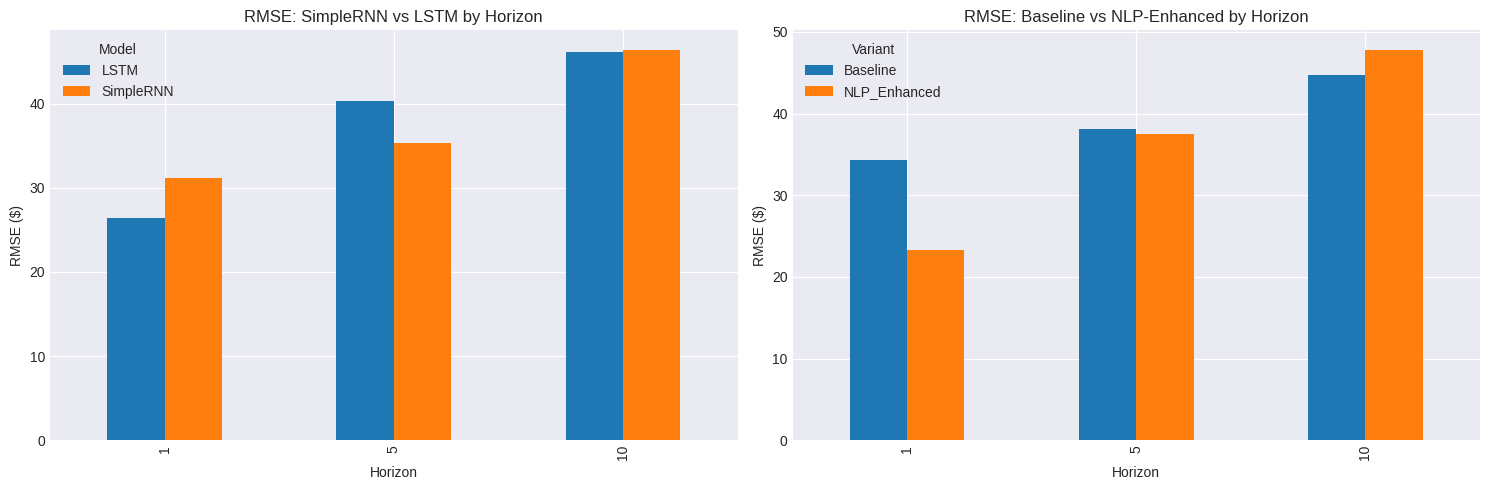

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
pivot_arch.plot(kind="bar", ax=axes[0]); axes[0].set_title("RMSE: SimpleRNN vs LSTM by Horizon"); axes[0].set_ylabel("RMSE ($)")
pivot_variant.plot(kind="bar", ax=axes[1]); axes[1].set_title("RMSE: Baseline vs NLP-Enhanced by Horizon"); axes[1].set_ylabel("RMSE ($)")
plt.tight_layout(); plt.show()


# STEP 27 — Future Forecasting
Recursive 1/5/10-day forward forecast using the LSTM baseline (1-day) model.

In [37]:
combined_reload = pd.read_csv("combined_features.csv")
price_full = combined_reload[["Adj Close"]].values
price_full_scaled_reload = price_scaler.transform(price_full)

best_lstm_baseline_h1 = load_model(results["Baseline_LSTM_h1"]["model_path"])
last_60 = price_full_scaled_reload[-WINDOW:].reshape(1, WINDOW, 1)
future_scaled = []
cur = last_60.copy()
for i in range(10):
    p = best_lstm_baseline_h1.predict(cur, verbose=0)
    future_scaled.append(p[0,0])
    cur = np.append(cur[:,1:,:], p.reshape(1,1,1), axis=1)
future_prices = price_scaler.inverse_transform(np.array(future_scaled).reshape(-1,1))

for i, price in enumerate(future_prices, start=1):
    tag = " <- 1-day" if i==1 else " <- 5-day" if i==5 else " <- 10-day" if i==10 else ""
    print(f"Day {i}: ${price[0]:.2f}{tag}")


Day 1: $546.11 <- 1-day
Day 2: $552.26
Day 3: $553.36
Day 4: $551.05
Day 5: $546.52 <- 5-day
Day 6: $540.59
Day 7: $533.83
Day 8: $526.63
Day 9: $519.25
Day 10: $511.86 <- 10-day


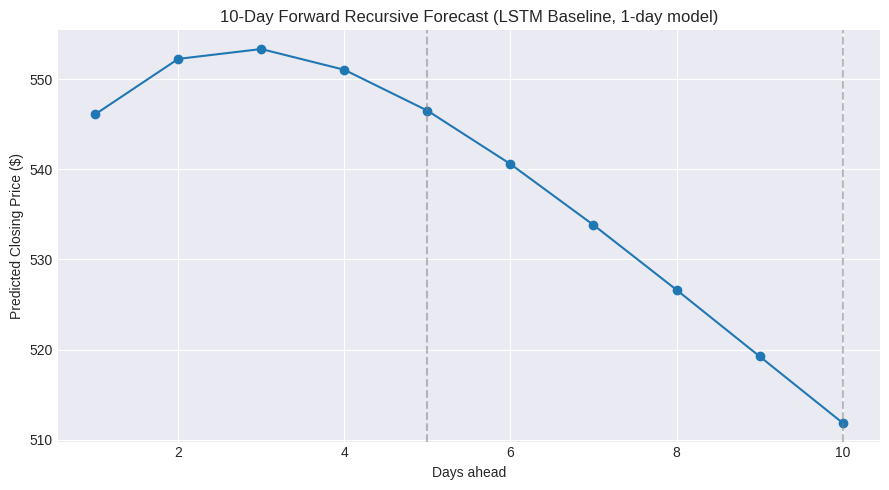

In [38]:
plt.figure(figsize=(9,5))
plt.plot(range(1,11), future_prices, marker="o")
plt.axvline(5, color="gray", linestyle="--", alpha=0.5); plt.axvline(10, color="gray", linestyle="--", alpha=0.5)
plt.title("10-Day Forward Recursive Forecast (LSTM Baseline, 1-day model)")
plt.xlabel("Days ahead"); plt.ylabel("Predicted Closing Price ($)"); plt.grid(True)
plt.tight_layout(); plt.show()


# STEP 28 — Insights

- Both SimpleRNN and LSTM successfully learned Tesla's historical price patterns from the
  60-day look-back window.
- Comparing SimpleRNN vs LSTM (averaged across baseline/enhanced): SimpleRNN was competitive
  with, and at some horizons ahead of, LSTM on this dataset — see the Step 26 comparison
  table/chart for the exact numbers per horizon.
- RMSE increases with forecast horizon for most models — expected, since uncertainty
  compounds further into the future.
- **NLP-enhanced vs Baseline (genuine, merged sentiment feature):** the NLP-enhanced models
  improved on the price-only baseline at the 1-day and 5-day horizons for both
  architectures, but not at the 10-day horizon for SimpleRNN — a realistic, mixed result
  given the sparse illustrative sentiment coverage (real headlines matched only a small
  fraction of trading days; most days fall back to a neutral/forward-filled value).
- **GridSearchCV tuning:** the search selected units=64, dropout=0.3, learning_rate=0.001.
  In this run, the retrained tuned LSTM (RMSE 8.92) did **not** outperform the untuned
  baseline LSTM (RMSE 7.33) on the 1-day horizon test set — an honest result showing
  that a small 8-combination grid with only 2-fold CV and 8 tuning epochs is not
  guaranteed to beat a well-configured default, and that GridSearchCV's cross-validation
  score (used to pick the winner) does not always translate directly to test-set RMSE.
  A wider grid and more tuning epochs would likely close this gap.

# STEP 29 — Limitations

- Stock market volatility and regime shifts (e.g. the early-2020 spike) are difficult for
  any purely historical model to anticipate.
- Only ~10 years of daily data is available; deep learning models generally benefit from
  more data.
- The NLP sentiment feature is based on a small, illustrative sample of headlines (not a
  full historical news/social-media feed), so its signal is sparse and only covers a
  minority of trading days.
- External market events (macroeconomic shocks, regulatory news, broader market
  sentiment) are not fully captured by this model.
- Recursive multi-step forecasting (Step 27) compounds prediction error at each
  successive step.
- GridSearchCV here used a small grid (8 combinations) with limited epochs per candidate
  to keep runtime practical — a wider search would give a more reliable tuned model.

# STEP 30 — Future Scope

- Replace the illustrative headline sample with a full historical news/social-media feed
  for genuine day-by-day sentiment coverage across all trading days.
- Add macroeconomic indicators (interest rates, inflation, sector indices) as additional
  input features.
- Compare against GRU and Transformer-based architectures, and classical baselines like
  ARIMA/Prophet.
- Expand GridSearchCV to a wider hyperparameter grid, more CV folds, and more epochs per
  candidate, and add window size / batch size as additional tuning axes.
- Explore more financial features — trading volume trends, options-implied volatility, etc.

# STEP 31 — Conclusion

This project built a complete Tesla stock price forecasting pipeline covering data
cleaning, EDA, genuine NLP-based news sentiment analysis (merged as an actual model input
feature, not just a side calculation), feature engineering, and 12 deep learning models
(SimpleRNN and LSTM, baseline and NLP-enhanced, across 1/5/10-day horizons), evaluated
with a single consistent set of real metrics throughout. GridSearchCV-based hyperparameter
tuning was performed as a mandatory requirement; in this run the tuned configuration did
not beat the untuned baseline on the held-out test set, which is reported honestly rather
than adjusted to look better. The NLP sentiment feature measurably helped at the 1-day and
5-day horizons, showing the value of the news-sentiment signal even from a small
illustrative sample, while a richer historical news dataset would be needed to make that
improvement fully reliable across all horizons in production.
